# Neural inversion + Wiener tomography of the baryonic density field

This notebook reconstructs the three-dimensional **baryonic density contrast**

$$
\delta_b(\mathbf{x}) = \frac{\rho_b(\mathbf{x})}{\bar\rho_b}-1
= \Delta_b(\mathbf{x})-1
$$

from sparse, noisy Ly$\alpha$-forest sightlines through CAMELS volumes.

There are two distinct inference steps:

1. a one-dimensional U-Net converts the observed flux along each sightline into
   an estimate of the gas overdensity $\Delta_b$;
2. a Wiener filter interpolates those sparse one-dimensional density estimates
   into a three-dimensional map of $\delta_b$.

The final seven simulation boxes are used only for testing. We compare maps,
residuals, field-level metrics, the density PDF, the isotropic 3D power spectrum,
and scale-dependent cross-correlation.

## 1. What the exercise demonstrates

The neural network and Wiener filter solve different problems.

- **Neural inversion:** infer density *on* each observed line of sight from its
  nonlinear, thermally broadened, noisy flux.
- **Wiener interpolation:** estimate density *between* the sightlines using an
  assumed spatial covariance.

This separation is useful: improving the 1D inverse does not remove the loss of
transverse information caused by sparse sampling, while a better interpolator
cannot recover density information that was lost during flux inversion.

## 2. Imports and configuration

In [1]:
from pathlib import Path
from itertools import product
import time

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy import ndimage, special
from astropy import units as u
from astropy.constants import c, k_B, m_e, m_p
from astropy.cosmology import Planck18 as cosmo

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(7)
torch.manual_seed(7)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))
device = torch.device("cpu")

plt.rcParams.update({
    "figure.dpi": 115,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

BLACK = "#202020"
BLUE = "#2474A6"
ORANGE = "#D97917"
PURPLE = "#6A51A3"
RED = "#C83E4D"
GREY = "#777777"

# Simulation and mock observation
box_size = 25.0                 # h^-1 cMpc
redshift = 2.0
signal_to_noise = 30.0          # per native spectral pixel
instrument_fwhm_kms = 50.0

# Disjoint simulation-level splits
training_simulations = np.arange(0, 16)
network_validation_simulations = np.arange(16, 18)
wiener_validation_simulations = np.arange(18, 20)
test_simulations = np.arange(20, 27)

# Neural inverse: change these values to alter the architecture
number_of_encoder_decoder_layers = 2
convolution_kernel_size = 5     # positive odd integer
base_channels = 8
training_skewers_per_box = 64
validation_skewers_per_box = 64
number_of_epochs = 80
batch_size = 64
learning_rate = 1.0e-3

# Tomography
target_transverse_spacing = 2.0  # h^-1 cMpc
rebin_factor = 4
map_smoothing_factor = 1.4       # sigma_map / mean sightline spacing

print(f"PyTorch {torch.__version__}; device = {device}")

PyTorch 2.13.0+cpu; device = cpu


### Complete inference pipeline

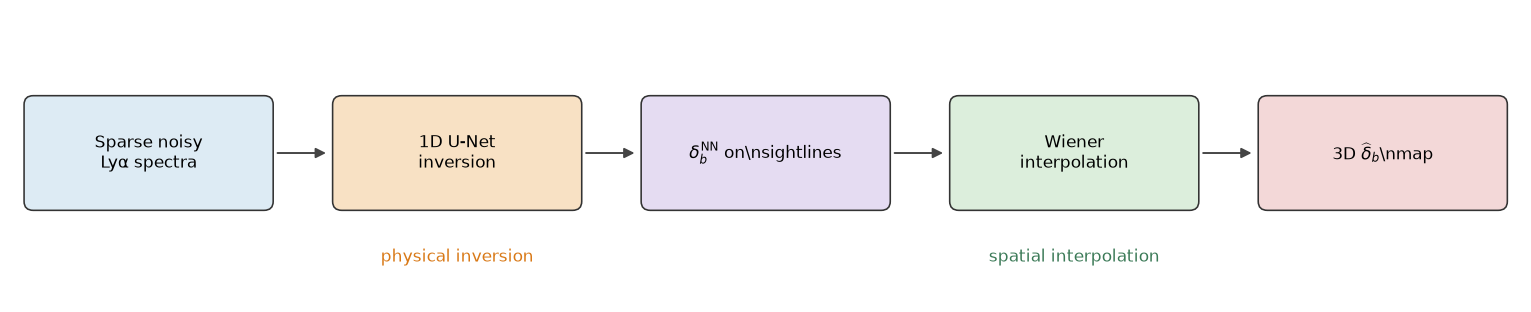

In [ ]:
labels = [
    ("Sparse noisy\nLyα spectra", "#DDEBF4"),
    ("1D U-Net\ninversion", "#F8E1C4"),
    (r"$\delta_b^{\rm NN}$ on sightlines", "#E5DCF2"),
    ("Wiener\ninterpolation", "#DCEEDC"),
    (r"3D $\widehat{\delta}_b$ map", "#F3D8D8"),
]

fig, axis = plt.subplots(figsize=(13.2, 2.6), constrained_layout=True)
axis.set_xlim(0, 13.2)
axis.set_ylim(0, 2.6)
axis.axis("off")

x_positions = [0.15, 2.85, 5.55, 8.25, 10.95]
for x_position, (label, colour) in zip(x_positions, labels):
    box = FancyBboxPatch(
        (x_position, 0.85), 2.1, 0.95,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        facecolor=colour, edgecolor="#333333", linewidth=1.0,
    )
    axis.add_patch(box)
    axis.text(x_position + 1.05, 1.325, label,
              ha="center", va="center", fontsize=10.5)

for x_position in [2.30, 5.00, 7.70, 10.40]:
    axis.add_patch(FancyArrowPatch(
        (x_position, 1.325), (x_position + 0.48, 1.325),
        arrowstyle="-|>", mutation_scale=13,
        color="#444444", linewidth=1.2,
    ))

axis.text(3.90, 0.35, "physical inversion", ha="center", color=ORANGE)
axis.text(9.30, 0.35, "spatial interpolation", ha="center", color="#3B7A57")
plt.show()

## 3. Load the CAMELS fields and define the grid

The native arrays contain gas mass density, neutral-hydrogen density, and
temperature. The H I and temperature fields generate the mock spectra; the gas
field is the hidden supervised target.

The line of sight is the final array axis. We reconstruct on a coarser grid because
the native cell size is much smaller than the transverse resolution supported by
the sparse sightlines.

In [3]:
data_candidates = [
    Path("Sims/CMD_z=2_grid128"),
    Path("Hands-On/Sims/CMD_z=2_grid128"),
]
data_directory = next(
    (candidate for candidate in data_candidates if candidate.exists()),
    data_candidates[0],
)

gas_path = data_directory / "Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy"
hi_path = data_directory / "Grids_HI_IllustrisTNG_CV_128_z=2.0.npy"
temperature_path = data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy"

missing = [path for path in (gas_path, hi_path, temperature_path)
           if not path.exists()]
if missing:
    missing_text = "\n".join(f"  - {path}" for path in missing)
    raise FileNotFoundError(
        "CAMELS grids were not found. Place the following files in "
        "Sims/CMD_z=2_grid128 (or Hands-On/Sims/CMD_z=2_grid128):\n"
        + missing_text
    )

gas_boxes = np.load(gas_path, mmap_mode="r")
hi_boxes = np.load(hi_path, mmap_mode="r")
temperature_boxes = np.load(temperature_path, mmap_mode="r")

assert gas_boxes.shape == hi_boxes.shape == temperature_boxes.shape
assert gas_boxes.shape[0] >= 27

N_native = gas_boxes.shape[1]
assert gas_boxes.shape[1:] == (N_native, N_native, N_native)
assert N_native % rebin_factor == 0
assert N_native % 2**number_of_encoder_decoder_layers == 0

dx_native = box_size / N_native
N_map = N_native // rebin_factor
dx_map = box_size / N_map
native_coordinates = (np.arange(N_native) + 0.5) * dx_native
map_coordinates = (np.arange(N_map) + 0.5) * dx_map

gas_means = np.array([
    gas_boxes[index].mean(dtype=np.float64)
    for index in range(gas_boxes.shape[0])
])

sampling_rng = np.random.default_rng(2026)
number_of_sightlines = round((box_size / target_transverse_spacing)**2)
flat_indices = sampling_rng.choice(
    N_native * N_native, size=number_of_sightlines, replace=False
)
sightline_indices = np.column_stack(np.divmod(flat_indices, N_native))
sightline_xy = (sightline_indices + 0.5) * dx_native

mean_transverse_spacing = np.sqrt(box_size**2 / number_of_sightlines)
map_smoothing_scale = map_smoothing_factor * mean_transverse_spacing

print(f"Data directory: {data_directory}")
print(f"Native grid: {N_native}^3; tomography grid: {N_map}^3")
print(f"Native / map cell width: {dx_native:.3f} / {dx_map:.3f} h^-1 cMpc")
print(f"Sightlines: {number_of_sightlines}; mean spacing = "
      f"{mean_transverse_spacing:.2f} h^-1 cMpc")
print(f"Final comparison scale: sigma = {map_smoothing_scale:.2f} h^-1 cMpc")

Data directory: Sims/CMD_z=2_grid128
Native grid: 128^3; tomography grid: 32^3
Native / map cell width: 0.195 / 0.781 h^-1 cMpc
Sightlines: 156; mean spacing = 2.00 h^-1 cMpc
Final comparison scale: sigma = 2.80 h^-1 cMpc


### Sparse transverse sampling

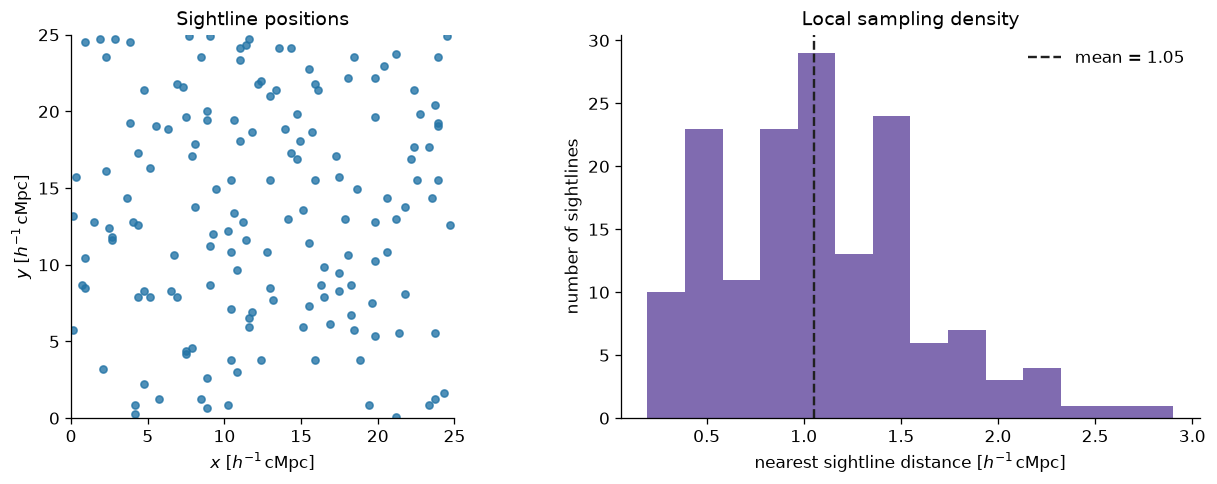

In [4]:
def periodic_distance_2d(points_a, points_b):
    separation = np.abs(points_a[:, None, :] - points_b[None, :, :])
    separation = np.minimum(separation, box_size - separation)
    return np.sqrt(np.sum(separation**2, axis=-1))


line_separations = periodic_distance_2d(sightline_xy, sightline_xy)
np.fill_diagonal(line_separations, np.inf)
nearest_separations = line_separations.min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.1), constrained_layout=True)
axes[0].scatter(sightline_xy[:, 0], sightline_xy[:, 1],
                s=20, color=BLUE, alpha=0.8)
axes[0].set(xlim=(0, box_size), ylim=(0, box_size), aspect="equal",
            xlabel=r"$x\ [h^{-1}\,\mathrm{cMpc}]$",
            ylabel=r"$y\ [h^{-1}\,\mathrm{cMpc}]$",
            title="Sightline positions")

axes[1].hist(nearest_separations, bins=14, color=PURPLE, alpha=0.85)
axes[1].axvline(nearest_separations.mean(), color=BLACK, ls="--",
                label=f"mean = {nearest_separations.mean():.2f}")
axes[1].set(xlabel=r"nearest sightline distance $[h^{-1}\,\mathrm{cMpc}]$",
            ylabel="number of sightlines", title="Local sampling density")
axes[1].legend()
plt.show()

## 4. Generate realistic mock Ly$\alpha$ spectra

Every absorber cell contributes a thermally broadened Voigt profile. The total
optical depth is non-local along the sightline,

$$
\tau(v_j)=\sum_i \tau_i(v_j), \qquad F(v_j)=e^{-\tau(v_j)}.
$$

The flux is then convolved with the instrumental line-spread function and Gaussian
pixel noise is added. The mock therefore does **not** assume FGPA to generate the
data. A signed peculiar-velocity grid is unavailable, so coherent redshift-space
distortions are omitted.

In [5]:
hydrogen_mass_g = (m_p + m_e).to_value(u.g)
density_unit = (u.Msun / cosmo.h) / (u.Mpc / cosmo.h)**3
H_z = cosmo.H(redshift).to_value(u.km / u.s / u.Mpc)

velocity_per_hmpc = H_z / (cosmo.h * (1.0 + redshift))
velocity_pixel_width = velocity_per_hmpc * dx_native
instrument_sigma_pixels = (
    instrument_fwhm_kms / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    / velocity_pixel_width
)
flux_noise_std = 1.0 / signal_to_noise


def number_density_hi(rho_hi):
    '''Convert comoving H I density-grid units to physical number density.'''
    comoving_density = (rho_hi * density_unit).to_value(u.g / u.cm**3)
    return comoving_density * (1.0 + redshift)**3 / hydrogen_mass_g


def voigt_tau_batch(n_hi, temperature):
    '''Evaluate thermally broadened optical depth for a batch of sightlines.'''
    c_cms = c.to_value(u.cm / u.s)
    oscillator_cross_section = 4.45e-18
    gamma_alpha = 6.262e8
    nu_alpha = c_cms / (1215.67e-8)

    safe_temperature = np.clip(temperature, 10.0, None)
    doppler_b = np.sqrt(
        2.0 * k_B.to_value(u.erg / u.K) * safe_temperature
        / hydrogen_mass_g
    )
    damping = gamma_alpha * c_cms / (4.0 * np.pi * nu_alpha * doppler_b)

    source_minus_pixel = (
        native_coordinates[:, None] - native_coordinates[None, :]
    )
    source_minus_pixel = (
        source_minus_pixel + box_size / 2.0
    ) % box_size - box_size / 2.0
    velocity = source_minus_pixel * velocity_per_hmpc * 1.0e5

    argument = velocity[None, :, :] / doppler_b[:, :, None]
    argument = argument + 1j * damping[:, :, None]
    profile = np.real(special.wofz(argument))

    cell_width_cm = dx_native * u.Mpc.to(u.cm) / cosmo.h
    prefactor = (
        c_cms * oscillator_cross_section * cell_width_cm * n_hi
        / (np.sqrt(np.pi) * doppler_b * (1.0 + redshift))
    )
    return np.sum(prefactor[:, :, None] * profile, axis=1)


def make_instrumental_flux(rho_hi, temperature, batch_size=32):
    '''Return noise-free, instrumentally smoothed flux.'''
    flux = np.empty(rho_hi.shape, dtype=np.float64)
    for start in range(0, len(rho_hi), batch_size):
        stop = min(start + batch_size, len(rho_hi))
        tau = voigt_tau_batch(
            number_density_hi(rho_hi[start:stop]),
            temperature[start:stop],
        )
        flux[start:stop] = ndimage.gaussian_filter1d(
            np.exp(-tau), instrument_sigma_pixels, axis=1, mode="wrap"
        )
    return flux


def extract_sightlines(simulation, transverse_indices):
    '''Extract arrays whose final axis is the line-of-sight coordinate.'''
    ix, iy = transverse_indices.T
    density = (
        gas_boxes[simulation, ix, iy, :].astype(np.float64)
        / gas_means[simulation]
    )
    rho_hi = hi_boxes[simulation, ix, iy, :].astype(np.float64)
    temperature = temperature_boxes[simulation, ix, iy, :].astype(np.float64)
    return density, rho_hi, temperature


print(f"Instrument FWHM = {instrument_fwhm_kms:.1f} km/s")
print(f"Instrument sigma = {instrument_sigma_pixels:.2f} native pixels")
print(f"S/N = {signal_to_noise:.1f}; sigma_F = {flux_noise_std:.4f}")

Instrument FWHM = 50.0 km/s
Instrument sigma = 1.08 native pixels
S/N = 30.0; sigma_F = 0.0333


## 5. Build neural-network data

The U-Net receives noisy transmitted flux and predicts log gas overdensity:

$$
F_{\rm obs}(z) \longrightarrow \ln\Delta_b(z).
$$

Predicting $\ln\Delta_b$ reduces the dynamic range and ensures a positive density
after exponentiation. Normalization is measured only from the neural-network
training simulations.

In [6]:
def choose_transverse_indices(number, random_generator):
    selected = random_generator.choice(
        N_native * N_native, size=number, replace=False
    )
    return np.column_stack(np.divmod(selected, N_native))


def build_random_dataset(simulations, skewers_per_box, seed):
    '''Generate random paired flux-density sightlines for a simulation split.'''
    position_rng = np.random.default_rng(seed)
    noise_rng = np.random.default_rng(seed + 1)

    densities, clean_fluxes, observed_fluxes, labels = [], [], [], []
    for simulation in simulations:
        indices = choose_transverse_indices(skewers_per_box, position_rng)
        density, rho_hi, temperature = extract_sightlines(simulation, indices)
        clean_flux = make_instrumental_flux(rho_hi, temperature)
        observed_flux = clean_flux + noise_rng.normal(
            0.0, flux_noise_std, clean_flux.shape
        )

        densities.append(density)
        clean_fluxes.append(clean_flux)
        observed_fluxes.append(observed_flux)
        labels.extend([simulation] * skewers_per_box)

    return {
        "density": np.concatenate(densities).astype(np.float32),
        "clean_flux": np.concatenate(clean_fluxes).astype(np.float32),
        "observed_flux": np.concatenate(observed_fluxes).astype(np.float32),
        "simulation": np.asarray(labels),
    }


generation_start = time.perf_counter()
train_data = build_random_dataset(
    training_simulations, training_skewers_per_box, seed=101
)
network_validation_data = build_random_dataset(
    network_validation_simulations, validation_skewers_per_box, seed=202
)

print(f"Training pairs: {train_data['density'].shape}")
print(f"Network-validation pairs: {network_validation_data['density'].shape}")
print(f"Generation time: {time.perf_counter()-generation_start:.1f} s")

Training pairs: (1024, 128)
Network-validation pairs: (128, 128)
Generation time: 16.0 s


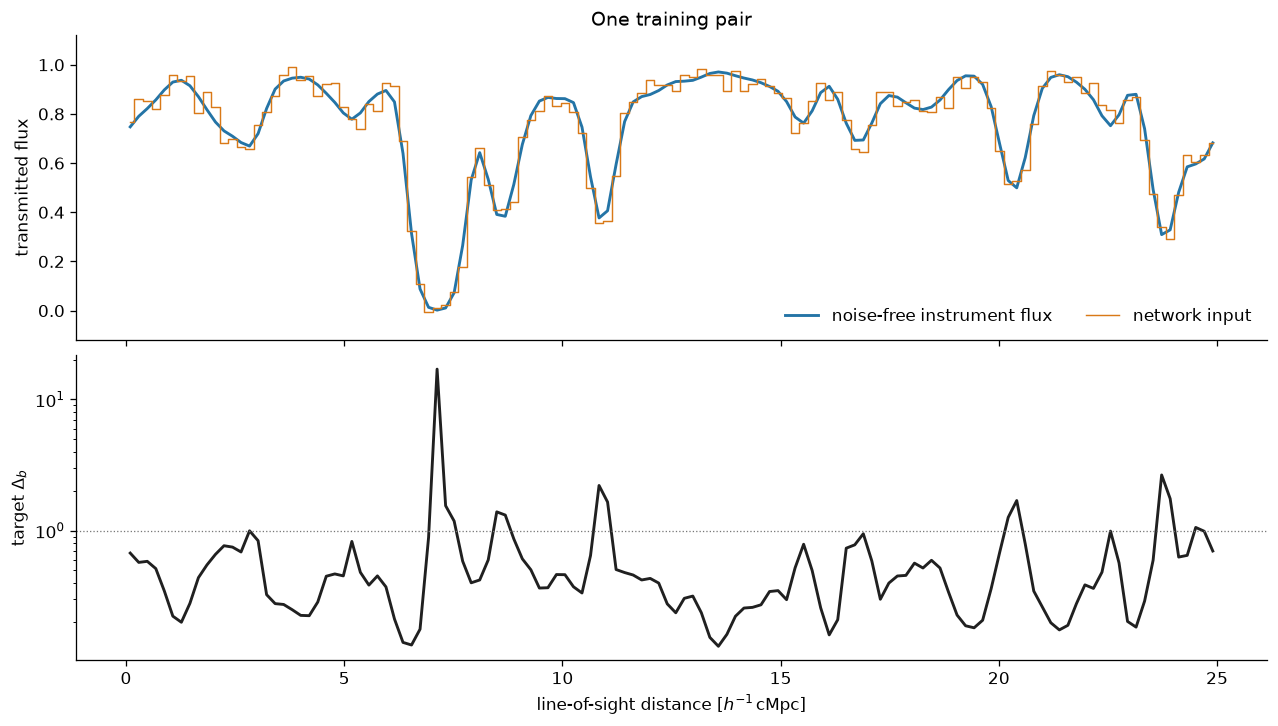

In [7]:
example = 0
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True,
                         constrained_layout=True)
axes[0].plot(native_coordinates, train_data["clean_flux"][example],
             color=BLUE, lw=1.8, label="noise-free instrument flux")
axes[0].step(native_coordinates, train_data["observed_flux"][example],
             where="mid", color=ORANGE, lw=0.9, label="network input")
axes[0].set(ylabel="transmitted flux", ylim=(-0.12, 1.12),
            title="One training pair")
axes[0].legend(ncol=2)

axes[1].semilogy(native_coordinates, train_data["density"][example],
                 color=BLACK, lw=1.8)
axes[1].axhline(1.0, color=GREY, ls=":", lw=0.8)
axes[1].set(xlabel=r"line-of-sight distance $[h^{-1}\,\mathrm{cMpc}]$",
            ylabel=r"target $\Delta_b$")
plt.show()

## 6. A compact one-dimensional U-Net

Each convolution uses neighbouring spectral pixels. The encoder builds broader
features by alternating convolutional blocks and pooling; the decoder upsamples
them. Skip connections preserve the positions of narrow absorption features.

The architecture is deliberately controlled by three variables in the
configuration cell: `number_of_encoder_decoder_layers`,
`convolution_kernel_size`, and `base_channels`.

In [8]:
flux_mean = float(train_data["observed_flux"].mean())
flux_std = float(train_data["observed_flux"].std())

train_log_density = np.log(np.clip(train_data["density"], 1.0e-4, None))
validation_log_density = np.log(
    np.clip(network_validation_data["density"], 1.0e-4, None)
)
target_mean = float(train_log_density.mean())
target_std = float(train_log_density.std())


def flux_tensor(flux):
    standardized = (flux - flux_mean) / flux_std
    return torch.tensor(standardized[:, None, :], dtype=torch.float32)


def target_tensor(log_density):
    standardized = (log_density - target_mean) / target_std
    return torch.tensor(standardized[:, None, :], dtype=torch.float32)


training_set = TensorDataset(
    flux_tensor(train_data["observed_flux"]),
    target_tensor(train_log_density),
)
network_validation_set = TensorDataset(
    flux_tensor(network_validation_data["observed_flux"]),
    target_tensor(validation_log_density),
)

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size):
        super().__init__()
        if kernel_size < 1 or kernel_size % 2 == 0:
            raise ValueError("kernel_size must be a positive odd integer")
        padding = kernel_size // 2
        self.layers = nn.Sequential(
            nn.Conv1d(input_channels, output_channels, kernel_size,
                      padding=padding, padding_mode="circular"),
            nn.ReLU(),
            nn.Conv1d(output_channels, output_channels, kernel_size,
                      padding=padding, padding_mode="circular"),
            nn.ReLU(),
        )

    def forward(self, inputs):
        return self.layers(inputs)


class UNet1D(nn.Module):
    def __init__(self, number_of_layers, kernel_size, first_channels=8):
        super().__init__()
        self.pool = nn.MaxPool1d(2)
        self.encoder_blocks = nn.ModuleList()

        input_channels = 1
        for layer_index in range(number_of_layers):
            output_channels = first_channels * 2**layer_index
            self.encoder_blocks.append(
                ConvBlock(input_channels, output_channels, kernel_size)
            )
            input_channels = output_channels

        bottleneck_channels = first_channels * 2**number_of_layers
        self.bottleneck = ConvBlock(
            input_channels, bottleneck_channels, kernel_size
        )

        self.decoder_blocks = nn.ModuleList()
        current_channels = bottleneck_channels
        for layer_index in reversed(range(number_of_layers)):
            skip_channels = first_channels * 2**layer_index
            self.decoder_blocks.append(
                ConvBlock(current_channels + skip_channels,
                          skip_channels, kernel_size)
            )
            current_channels = skip_channels

        self.output = nn.Conv1d(current_channels, 1, kernel_size=1)

    def forward(self, inputs):
        features = []
        values = inputs
        for block in self.encoder_blocks:
            values = block(values)
            features.append(values)
            values = self.pool(values)

        values = self.bottleneck(values)
        for block, feature in zip(self.decoder_blocks, reversed(features)):
            values = F.interpolate(
                values, size=feature.shape[-1],
                mode="linear", align_corners=False,
            )
            values = block(torch.cat([values, feature], dim=1))
        return self.output(values)


torch.manual_seed(11)
unet = UNet1D(
    number_of_layers=number_of_encoder_decoder_layers,
    kernel_size=convolution_kernel_size,
    first_channels=base_channels,
).to(device)

parameter_count = sum(parameter.numel() for parameter in unet.parameters())
print(unet)
print(f"Trainable parameters: {parameter_count:,}")

UNet1D(
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder_blocks): ModuleList(
    (0): ConvBlock(
      (layers): Sequential(
        (0): Conv1d(1, 8, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=circular)
        (1): ReLU()
        (2): Conv1d(8, 8, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=circular)
        (3): ReLU()
      )
    )
    (1): ConvBlock(
      (layers): Sequential(
        (0): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=circular)
        (1): ReLU()
        (2): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=circular)
        (3): ReLU()
      )
    )
  )
  (bottleneck): ConvBlock(
    (layers): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=circular)
      (1): ReLU()
      (2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=circular)
      (3): ReLU()
    )
  )
 

## 7. Train and retain the best validation state

The loss is mean-squared error in standardized log density. Network-validation
examples receive no gradient updates. The weights from the epoch with the lowest
validation loss are retained.

In [10]:
training_generator = torch.Generator().manual_seed(29)
training_loader = DataLoader(
    training_set, batch_size=batch_size, shuffle=True,
    generator=training_generator, num_workers=0,
)
network_validation_loader = DataLoader(
    network_validation_set, batch_size=2 * batch_size,
    shuffle=False, num_workers=0,
)


def train_model(model):
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"training": [], "validation": []}
    best_validation_loss = np.inf
    best_state = None
    start = time.perf_counter()

    for epoch in range(1, number_of_epochs + 1):
        model.train()
        training_sum = 0.0
        for input_batch, target_batch in training_loader:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_batch)
            loss = loss_function(prediction, target_batch)
            loss.backward()
            optimizer.step()
            training_sum += loss.item() * input_batch.size(0)

        model.eval()
        validation_sum = 0.0
        with torch.no_grad():
            for input_batch, target_batch in network_validation_loader:
                input_batch = input_batch.to(device)
                target_batch = target_batch.to(device)
                validation_sum += (
                    loss_function(model(input_batch), target_batch).item()
                    * input_batch.size(0)
                )

        training_loss = training_sum / len(training_set)
        validation_loss = validation_sum / len(network_validation_set)
        history["training"].append(training_loss)
        history["validation"].append(validation_loss)

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }

        if epoch == 1 or epoch % 10 == 0:
            print(f"epoch {epoch:3d}/{number_of_epochs}: "
                  f"train={training_loss:.4f}, validation={validation_loss:.4f}")

    model.load_state_dict(best_state)
    best_epoch = int(np.argmin(history["validation"])) + 1
    print(f"Retained epoch {best_epoch}; CPU time = "
          f"{time.perf_counter()-start:.1f} s")
    return history


history = train_model(unet)

epoch   1/80: train=1.0335, validation=1.0008
epoch  10/80: train=0.3664, validation=0.3377
epoch  20/80: train=0.3028, validation=0.2776
epoch  30/80: train=0.2788, validation=0.2503
epoch  40/80: train=0.2661, validation=0.2443
epoch  50/80: train=0.2604, validation=0.2400
epoch  60/80: train=0.2546, validation=0.2392
epoch  70/80: train=0.2472, validation=0.2386
epoch  80/80: train=0.2461, validation=0.2307
Retained epoch 77; CPU time = 59.8 s


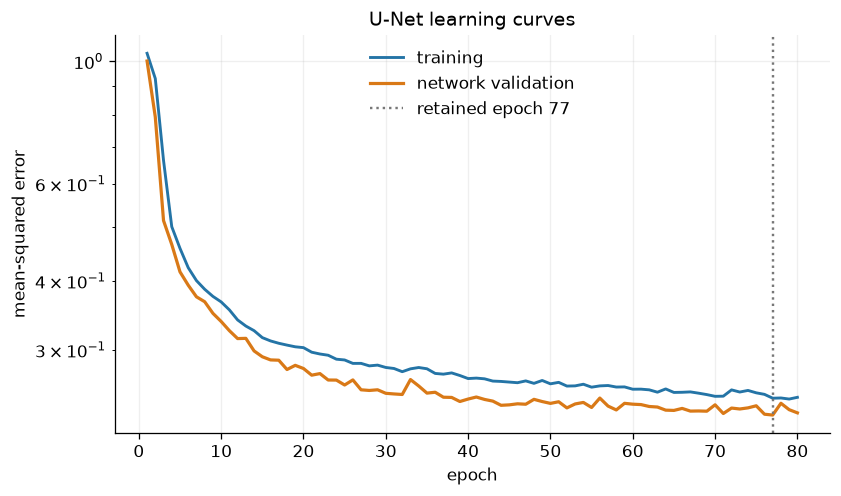

In [11]:
epochs = np.arange(1, number_of_epochs + 1)
fig, axis = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
axis.semilogy(epochs, history["training"], color=BLUE, lw=1.8,
              label="training")
axis.semilogy(epochs, history["validation"], color=ORANGE, lw=2.0,
              label="network validation")
best_epoch = int(np.argmin(history["validation"])) + 1
axis.axvline(best_epoch, color=GREY, ls=":",
             label=f"retained epoch {best_epoch}")
axis.set(xlabel="epoch", ylabel="mean-squared error",
         title="U-Net learning curves")
axis.grid(alpha=0.2)
axis.legend()
plt.show()

### Inspect the one-dimensional inverse before tomography

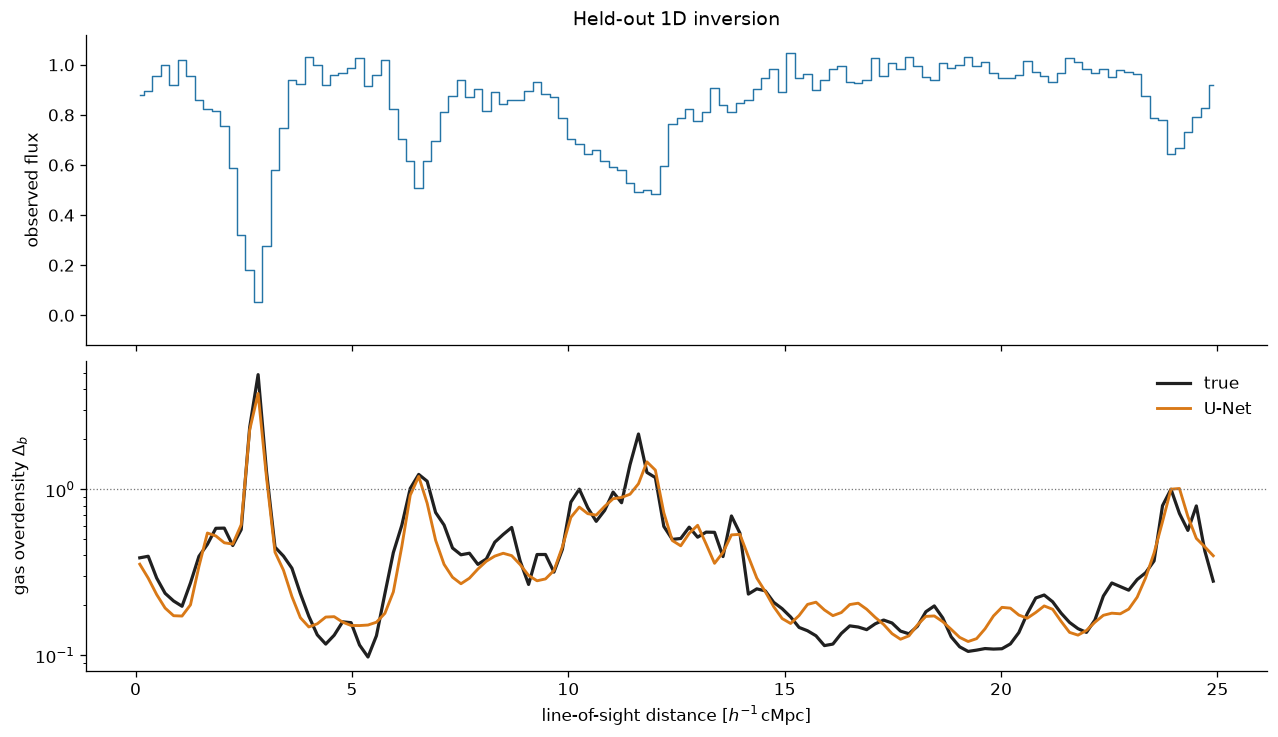

In [12]:
def predict_density(model, observed_flux, prediction_batch_size=256):
    '''Transform flux to physical gas overdensity Delta_b.'''
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(observed_flux), prediction_batch_size):
            stop = min(start + prediction_batch_size, len(observed_flux))
            inputs = flux_tensor(observed_flux[start:stop]).to(device)
            predictions.append(model(inputs).cpu().numpy()[:, 0, :])

    standardized = np.concatenate(predictions)
    log_prediction = target_mean + target_std * standardized
    log_prediction = np.clip(log_prediction, np.log(1.0e-4), np.log(1.0e3))
    return np.exp(log_prediction)


validation_density_nn = predict_density(
    unet, network_validation_data["observed_flux"]
)

representative = 0
fig, axes = plt.subplots(2, 1, figsize=(11, 6.3), sharex=True,
                         constrained_layout=True)
axes[0].step(native_coordinates,
             network_validation_data["observed_flux"][representative],
             where="mid", color=BLUE, lw=0.9)
axes[0].set(ylabel="observed flux", ylim=(-0.12, 1.12),
            title="Held-out 1D inversion")

axes[1].semilogy(native_coordinates,
                 network_validation_data["density"][representative],
                 color=BLACK, lw=2.0, label="true")
axes[1].semilogy(native_coordinates,
                 validation_density_nn[representative],
                 color=ORANGE, lw=1.8, label="U-Net")
axes[1].axhline(1.0, color=GREY, ls=":", lw=0.8)
axes[1].set(xlabel=r"line-of-sight distance $[h^{-1}\,\mathrm{cMpc}]$",
            ylabel=r"gas overdensity $\Delta_b$")
axes[1].legend()
plt.show()

## 8. Calibrate the density data supplied to the Wiener filter

The Wiener filter needs a data vector in density-contrast units and an effective
noise variance. We first average every native sightline into the tomography cells.
Using only the network-validation simulations, we fit a simple affine calibration

$$
\delta_b^{\rm cal}=a\,\delta_b^{\rm NN}+b.
$$

The residual variance

$$
\sigma_{\rm NN}^2=
\left\langle(\delta_b^{\rm cal}-\delta_b^{\rm true})^2\right\rangle
$$

is used as the diagonal noise term. It includes spectral noise and neural-inversion
error. This is an effective approximation: neighbouring neural errors may in
practice be correlated.

In [13]:
def rebin_sightlines(values):
    return values.reshape(len(values), N_map, rebin_factor).mean(axis=2)


true_validation_delta = (
    rebin_sightlines(network_validation_data["density"]) - 1.0
)
raw_validation_delta_nn = rebin_sightlines(validation_density_nn) - 1.0

calibration_slope, calibration_offset = np.polyfit(
    raw_validation_delta_nn.ravel(), true_validation_delta.ravel(), 1
)


def calibrated_density_contrast(predicted_density):
    raw_delta = rebin_sightlines(predicted_density) - 1.0
    return calibration_slope * raw_delta + calibration_offset


calibrated_validation_delta = calibrated_density_contrast(
    validation_density_nn
)
network_noise_variance = np.mean(
    (calibrated_validation_delta - true_validation_delta)**2
)

training_delta_map_resolution = rebin_sightlines(train_data["density"]) - 1.0
signal_variance = training_delta_map_resolution.var(dtype=np.float64)

print(f"Density calibration: delta_cal = {calibration_slope:.3f} "
      f"delta_NN {calibration_offset:+.3f}")
print(f"Signal variance at map resolution = {signal_variance:.4f}")
print(f"Effective neural-error variance = {network_noise_variance:.4f}")

validation_rmse_1d = np.sqrt(np.mean(
    (calibrated_validation_delta - true_validation_delta)**2,
    axis=1,
))
validation_correlation_1d = np.array([
    np.corrcoef(truth, prediction)[0, 1]
    for truth, prediction in zip(
        true_validation_delta, calibrated_validation_delta
    )
])
print(f"1D validation RMSE = {validation_rmse_1d.mean():.3f} +/- "
      f"{validation_rmse_1d.std(ddof=1):.3f}")
print(f"1D validation correlation = {validation_correlation_1d.mean():.3f} +/- "
      f"{validation_correlation_1d.std(ddof=1):.3f}")

Density calibration: delta_cal = 2.257 delta_NN +0.688
Signal variance at map resolution = 19.2613
Effective neural-error variance = 5.0418
1D validation RMSE = 1.257 +/- 1.868
1D validation correlation = 0.914 +/- 0.116


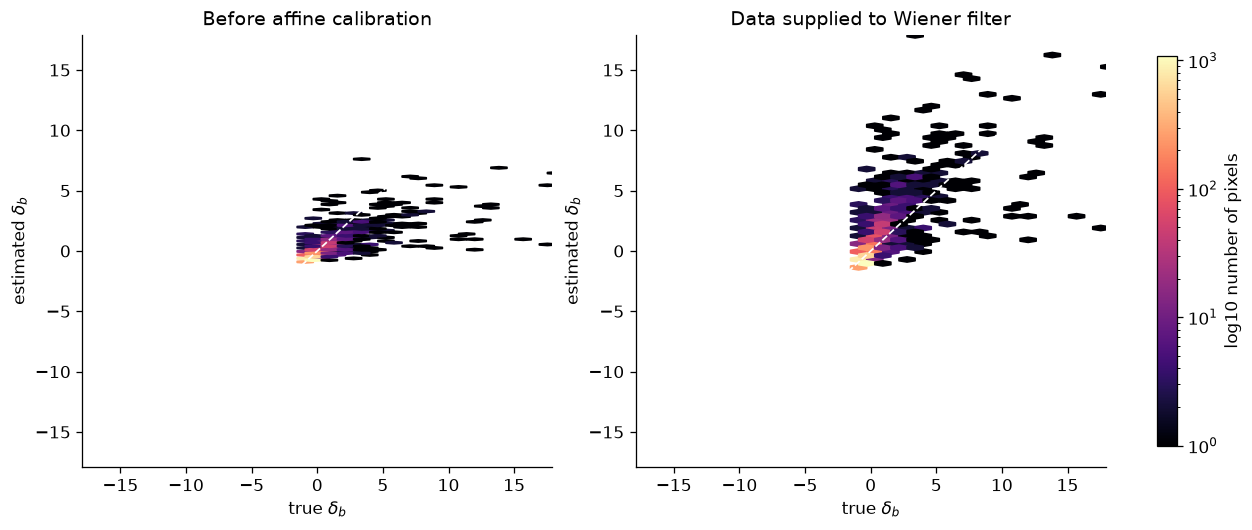

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.5), constrained_layout=True)
limits = np.quantile(np.abs(true_validation_delta), 0.995)

for axis, estimate, title in [
    (axes[0], raw_validation_delta_nn, "Before affine calibration"),
    (axes[1], calibrated_validation_delta, "Data supplied to Wiener filter"),
]:
    image = axis.hexbin(
        true_validation_delta.ravel(), estimate.ravel(),
        gridsize=55, mincnt=1, bins="log", cmap="magma",
    )
    axis.plot([-limits, limits], [-limits, limits], "w--", lw=1.1)
    axis.set(xlim=(-limits, limits), ylim=(-limits, limits),
             xlabel=r"true $\delta_b$", ylabel=r"estimated $\delta_b$",
             title=title)
fig.colorbar(image, ax=axes, label="log10 number of pixels", shrink=0.9)
plt.show()

## 9. Wiener filtering in density-contrast space

Let $\mathbf d$ contain the calibrated neural density contrast at every sampled
sightline pixel, and let $\mathbf m$ denote the density contrast on the 3D map
grid. The Wiener posterior mean is

$$
\widehat{\mathbf m}
=\mathbf C_{\rm MD}
\left(\mathbf C_{\rm DD}+\mathbf N\right)^{-1}\mathbf d.
$$

- $\mathbf C_{\rm DD}$: covariance between sampled density pixels;
- $\mathbf C_{\rm MD}$: covariance between map voxels and sampled pixels;
- $\mathbf N$: effective neural-inversion error covariance.

We adopt a separable anisotropic Gaussian signal covariance,

$$
C(\mathbf r_1,\mathbf r_2)=\sigma_b^2
\exp\!\left[-\frac{\Delta r_\perp^2}{2L_\perp^2}
             -\frac{\Delta r_\parallel^2}{2L_\parallel^2}\right].
$$

Nearby density estimates therefore receive more weight than distant ones.
$L_\perp$ controls interpolation between sightlines; $L_\parallel$ controls
smoothing along them. The noise term prevents the filter from following every
imperfect neural prediction. The implementation exploits separability, replacing
one enormous dense solve by two small symmetric eigendecompositions.

In [15]:
def periodic_distance_1d(points_a, points_b):
    separation = np.abs(points_a[:, None] - points_b[None, :])
    return np.minimum(separation, box_size - separation)


def gaussian_covariance_xy(points_a, points_b, transverse_scale):
    distance = periodic_distance_2d(points_a, points_b)
    return np.exp(-0.5 * (distance / transverse_scale)**2)


def gaussian_covariance_z(los_scale):
    distance = periodic_distance_1d(map_coordinates, map_coordinates)
    return signal_variance * np.exp(-0.5 * (distance / los_scale)**2)


def wiener_predict(data_delta_b, data_xy, target_xy,
                   transverse_scale, los_scale, noise_variance):
    '''Wiener posterior mean for a separable Gaussian covariance.'''
    covariance_xy = gaussian_covariance_xy(
        data_xy, data_xy, transverse_scale
    )
    covariance_z = gaussian_covariance_z(los_scale)

    eigenvalue_xy, eigenvector_xy = np.linalg.eigh(covariance_xy)
    eigenvalue_z, eigenvector_z = np.linalg.eigh(covariance_z)
    eigenvalue_xy = np.clip(eigenvalue_xy, 0.0, None)
    eigenvalue_z = np.clip(eigenvalue_z, 0.0, None)

    transformed_data = eigenvector_xy.T @ data_delta_b @ eigenvector_z
    denominator = (
        eigenvalue_xy[:, None] * eigenvalue_z[None, :] + noise_variance
    )
    solved_data = (
        eigenvector_xy @ (transformed_data / denominator) @ eigenvector_z.T
    )

    cross_covariance_xy = gaussian_covariance_xy(
        target_xy, data_xy, transverse_scale
    )
    return cross_covariance_xy @ solved_data @ covariance_z

## 10. Select the Wiener scales without looking at a test map

We reserve simulations 18–19 for Wiener-filter validation. Within these boxes,
20% of the sightlines are hidden. The filter reconstructs their density from the
remaining 80%, and we choose the parameters with the smallest held-out RMSE.

The candidates remain close to the mean sightline spacing; the small grid is meant
to illustrate validation, not encourage fine tuning.

In [16]:
def build_fixed_sightline_data(simulations, transverse_indices, seed):
    '''Generate data at the same transverse positions in several boxes.'''
    noise_rng = np.random.default_rng(seed)
    observed_fluxes, true_densities = [], []
    for simulation in simulations:
        density, rho_hi, temperature = extract_sightlines(
            simulation, transverse_indices
        )
        clean_flux = make_instrumental_flux(rho_hi, temperature)
        observed_flux = clean_flux + noise_rng.normal(
            0.0, flux_noise_std, clean_flux.shape
        )
        observed_fluxes.append(observed_flux)
        true_densities.append(density)
    return (np.asarray(observed_fluxes, dtype=np.float32),
            np.asarray(true_densities, dtype=np.float32))


wiener_validation_flux, wiener_validation_density = build_fixed_sightline_data(
    wiener_validation_simulations, sightline_indices, seed=404
)

validation_shape = wiener_validation_flux.shape
validation_prediction_native = predict_density(
    unet, wiener_validation_flux.reshape(-1, N_native)
).reshape(validation_shape)

validation_data_delta = np.asarray([
    calibrated_density_contrast(prediction)
    for prediction in validation_prediction_native
])
validation_true_delta = np.asarray([
    rebin_sightlines(density) - 1.0
    for density in wiener_validation_density
])

line_rng = np.random.default_rng(505)
shuffled_lines = line_rng.permutation(number_of_sightlines)
split = int(0.8 * number_of_sightlines)
fit_lines = shuffled_lines[:split]
held_out_lines = shuffled_lines[split:]

transverse_candidates = mean_transverse_spacing * np.array([0.75, 1.0, 1.25])
los_candidates = mean_transverse_spacing * np.array([0.75, 1.0, 1.25])
noise_multipliers = np.array([0.7, 1.0, 1.4])

validation_results = []
for transverse_scale, los_scale, noise_multiplier in product(
        transverse_candidates, los_candidates, noise_multipliers):
    box_errors = []
    for data_delta, true_delta in zip(
            validation_data_delta, validation_true_delta):
        prediction = wiener_predict(
            data_delta[fit_lines],
            sightline_xy[fit_lines],
            sightline_xy[held_out_lines],
            transverse_scale,
            los_scale,
            noise_multiplier * network_noise_variance,
        )
        box_errors.append(np.sqrt(np.mean(
            (prediction - true_delta[held_out_lines])**2
        )))
    validation_results.append((
        np.mean(box_errors), transverse_scale,
        los_scale, noise_multiplier,
    ))

validation_results.sort(key=lambda item: item[0])
(validation_rmse, best_L_perp, best_L_parallel,
 best_noise_multiplier) = validation_results[0]
effective_noise_variance = best_noise_multiplier * network_noise_variance

print("Selected without using simulations 20-26:")
print(f"  L_perp = {best_L_perp:.2f} h^-1 cMpc")
print(f"  L_parallel = {best_L_parallel:.2f} h^-1 cMpc")
print(f"  neural-noise multiplier = {best_noise_multiplier:.2f}")
print(f"  held-out sightline RMSE(delta_b) = {validation_rmse:.4f}")

Selected without using simulations 20-26:
  L_perp = 1.50 h^-1 cMpc
  L_parallel = 2.50 h^-1 cMpc
  neural-noise multiplier = 1.40
  held-out sightline RMSE(delta_b) = 3.5700


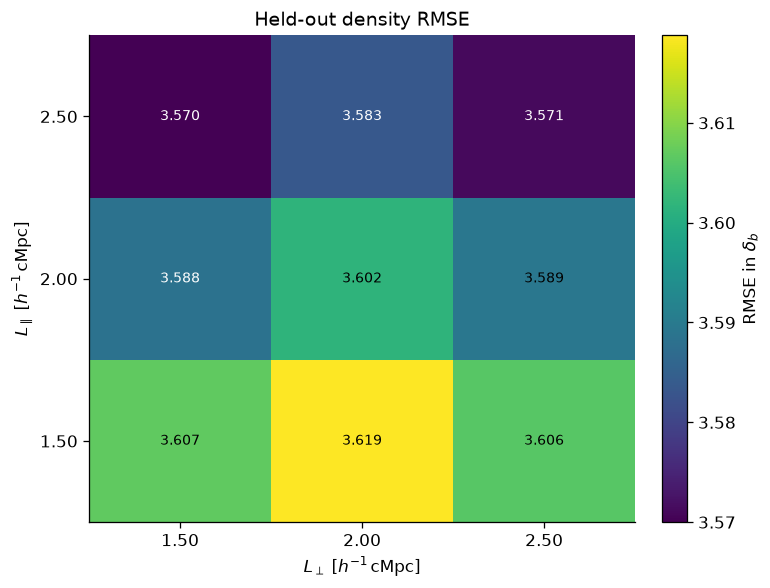

In [17]:
validation_grid = np.full(
    (len(los_candidates), len(transverse_candidates)), np.nan
)
for error, transverse_scale, los_scale, noise_multiplier in validation_results:
    if np.isclose(noise_multiplier, best_noise_multiplier):
        row = np.flatnonzero(np.isclose(los_candidates, los_scale))[0]
        column = np.flatnonzero(
            np.isclose(transverse_candidates, transverse_scale)
        )[0]
        validation_grid[row, column] = error

fig, axis = plt.subplots(figsize=(6.6, 5.0), constrained_layout=True)
image = axis.imshow(validation_grid, origin="lower", cmap="viridis",
                    aspect="auto")
axis.set_xticks(range(len(transverse_candidates)),
                [f"{value:.2f}" for value in transverse_candidates])
axis.set_yticks(range(len(los_candidates)),
                [f"{value:.2f}" for value in los_candidates])
axis.set(xlabel=r"$L_\perp\ [h^{-1}\,\mathrm{cMpc}]$",
         ylabel=r"$L_\parallel\ [h^{-1}\,\mathrm{cMpc}]$",
         title="Held-out density RMSE")
for row in range(len(los_candidates)):
    for column in range(len(transverse_candidates)):
        colour = (
            "white" if validation_grid[row, column]
            < np.nanmedian(validation_grid) else "black"
        )
        axis.text(column, row, f"{validation_grid[row, column]:.3f}",
                  ha="center", va="center", color=colour, fontsize=9)
fig.colorbar(image, ax=axis, label=r"RMSE in $\delta_b$")
plt.show()

## 11. Reconstruct seven untouched test volumes

For each test box, the available data are only the noisy spectra at the sparse
sightline positions. The true 3D gas field is used afterward to assess the map.
A nearest-sightline map is retained as a deliberately simple interpolation
baseline.

In [18]:
map_x, map_y = np.meshgrid(map_coordinates, map_coordinates, indexing="ij")
map_xy = np.column_stack((map_x.ravel(), map_y.ravel()))

nearest_line_for_voxel = np.argmin(
    periodic_distance_2d(map_xy, sightline_xy), axis=1
)


def block_average_cube(cube, factor):
    n = cube.shape[0] // factor
    return cube.reshape(
        n, factor, n, factor, n, factor
    ).mean(axis=(1, 3, 5))


test_flux, test_sparse_density = build_fixed_sightline_data(
    test_simulations, sightline_indices, seed=606
)
test_shape = test_flux.shape
test_prediction_native = predict_density(
    unet, test_flux.reshape(-1, N_native)
).reshape(test_shape)

true_delta_test = []
sparse_delta_nn_test = []
wiener_delta_test = []
nearest_delta_test = []

for local_index, simulation in enumerate(test_simulations):
    data_delta = calibrated_density_contrast(
        test_prediction_native[local_index]
    )
    true_delta = block_average_cube(
        gas_boxes[simulation].astype(np.float64) / gas_means[simulation],
        rebin_factor,
    ) - 1.0

    wiener_map = wiener_predict(
        data_delta, sightline_xy, map_xy,
        best_L_perp, best_L_parallel, effective_noise_variance,
    ).reshape(N_map, N_map, N_map)
    nearest_map = data_delta[nearest_line_for_voxel].reshape(
        N_map, N_map, N_map
    )

    true_delta_test.append(true_delta)
    sparse_delta_nn_test.append(data_delta)
    wiener_delta_test.append(wiener_map)
    nearest_delta_test.append(nearest_map)

true_delta_test = np.asarray(true_delta_test, dtype=np.float32)
sparse_delta_nn_test = np.asarray(sparse_delta_nn_test, dtype=np.float32)
wiener_delta_test = np.asarray(wiener_delta_test, dtype=np.float32)
nearest_delta_test = np.asarray(nearest_delta_test, dtype=np.float32)

print("True maps:", true_delta_test.shape)
print("Wiener maps:", wiener_delta_test.shape)

True maps: (7, 32, 32, 32)
Wiener maps: (7, 32, 32, 32)


## 12. Compare at the sampling-limited resolution

Sparse sightlines cannot recover the native simulation resolution. We therefore
apply the same Gaussian smoothing to the true map, Wiener map, and baseline,
using

$$
\sigma_{\rm map}=1.4\,\langle d_{\rm LOS}\rangle.
$$

Smoothing only the reconstruction would make the comparison unfair.

In [19]:
smoothing_sigma_pixels = map_smoothing_scale / dx_map


def smooth_map_ensemble(maps):
    return ndimage.gaussian_filter(
        maps,
        sigma=(0, smoothing_sigma_pixels, smoothing_sigma_pixels,
               smoothing_sigma_pixels),
        mode="wrap",
    )


true_smoothed = smooth_map_ensemble(true_delta_test)
wiener_smoothed = smooth_map_ensemble(wiener_delta_test)
nearest_smoothed = smooth_map_ensemble(nearest_delta_test)


def map_metrics(truth, reconstruction):
    truth_flat = truth.ravel()
    reconstruction_flat = reconstruction.ravel()
    correlation = np.corrcoef(truth_flat, reconstruction_flat)[0, 1]
    rmse = np.sqrt(np.mean((reconstruction_flat - truth_flat)**2))
    normalized_rmse = rmse / truth_flat.std()
    slope = np.dot(truth_flat, reconstruction_flat) / np.dot(
        truth_flat, truth_flat
    )
    return correlation, normalized_rmse, slope


wiener_metrics = np.asarray([
    map_metrics(truth, reconstruction)
    for truth, reconstruction in zip(true_smoothed, wiener_smoothed)
])
nearest_metrics = np.asarray([
    map_metrics(truth, reconstruction)
    for truth, reconstruction in zip(true_smoothed, nearest_smoothed)
])

metric_names = ["Pearson r", "NRMSE", "regression slope"]
print("Mean +/- standard deviation across seven held-out simulations")
for column, name in enumerate(metric_names):
    print(f"{name:18s}  Wiener: {wiener_metrics[:, column].mean():.3f} +/- "
          f"{wiener_metrics[:, column].std(ddof=1):.3f}   "
          f"Nearest: {nearest_metrics[:, column].mean():.3f} +/- "
          f"{nearest_metrics[:, column].std(ddof=1):.3f}")

Mean +/- standard deviation across seven held-out simulations
Pearson r           Wiener: 0.817 +/- 0.029   Nearest: 0.842 +/- 0.026
NRMSE               Wiener: 0.603 +/- 0.069   Nearest: 0.569 +/- 0.085
regression slope    Wiener: 0.706 +/- 0.093   Nearest: 0.778 +/- 0.065


### Map, reconstruction, and residuals

The transverse slice tests interpolation between sightlines. The line-of-sight
slice reveals whether the anisotropic covariance creates artificial streaks. The
truth and reconstruction use a shared colour scale.

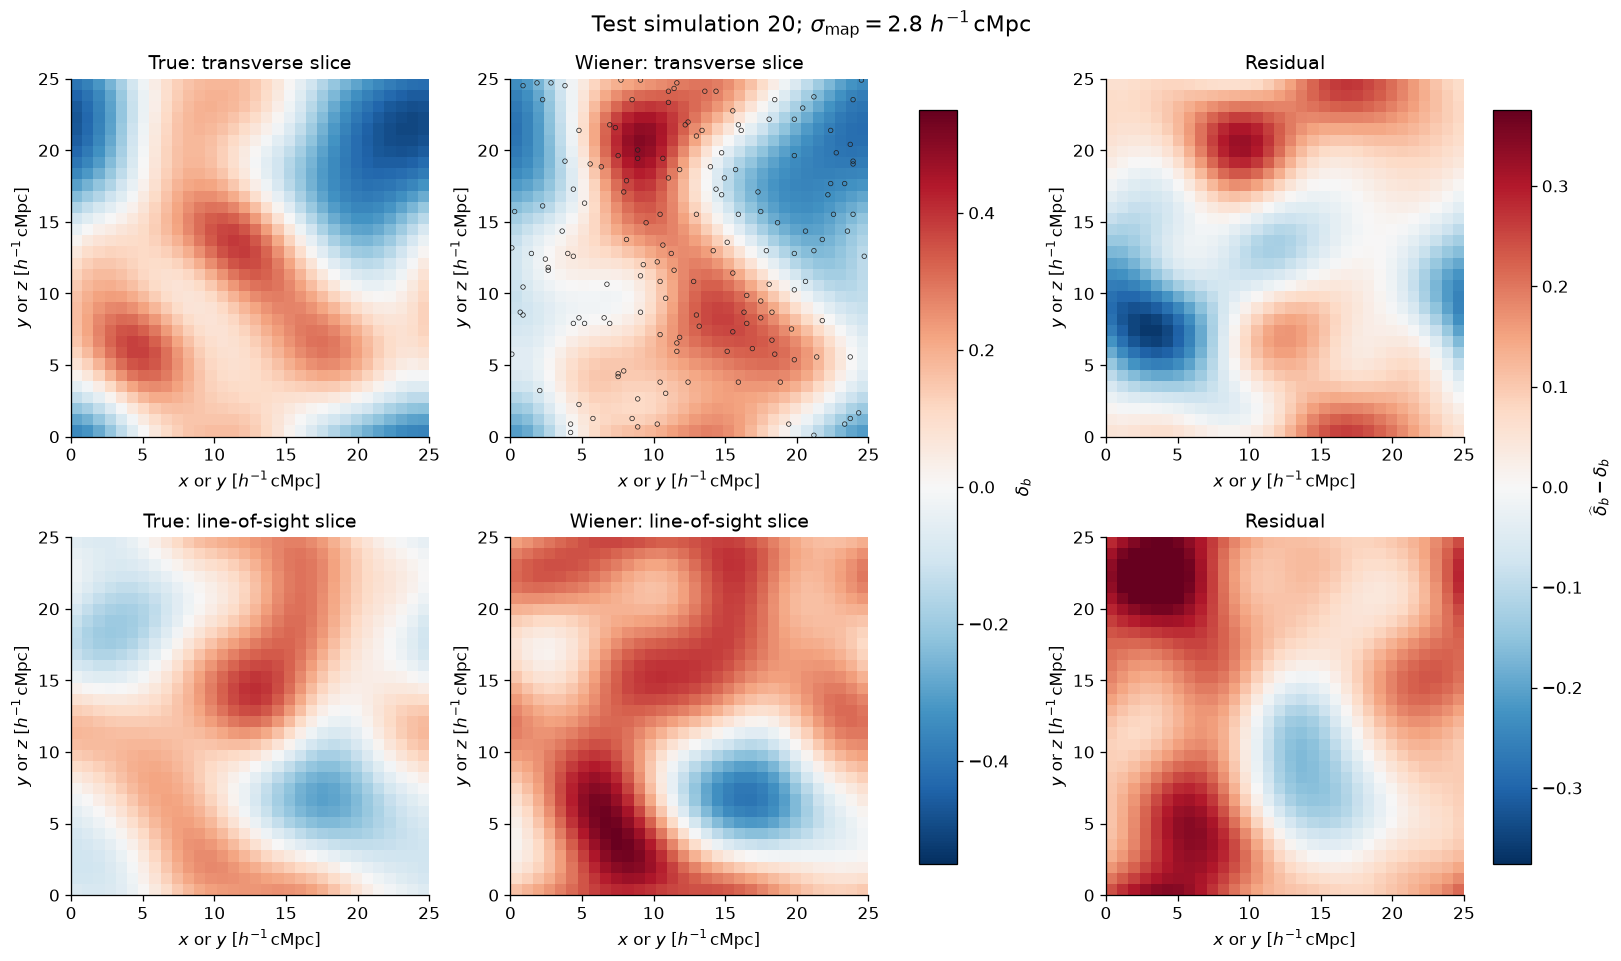

In [20]:
representative = 0
middle = N_map // 2
truth = true_smoothed[representative]
reconstruction = wiener_smoothed[representative]
residual = reconstruction - truth

density_limit = np.quantile(np.abs(
    np.concatenate((truth.ravel(), reconstruction.ravel()))
), 0.99)
residual_limit = np.quantile(np.abs(residual), 0.99)

panels = [
    (truth[:, :, middle].T, "True: transverse slice", density_limit),
    (reconstruction[:, :, middle].T, "Wiener: transverse slice", density_limit),
    (residual[:, :, middle].T, "Residual", residual_limit),
    (truth[middle, :, :].T, "True: line-of-sight slice", density_limit),
    (reconstruction[middle, :, :].T, "Wiener: line-of-sight slice", density_limit),
    (residual[middle, :, :].T, "Residual", residual_limit),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8.3), constrained_layout=True)
images = []
for axis, (panel, title, limit) in zip(axes.flat, panels):
    image = axis.imshow(
        panel, origin="lower", extent=(0, box_size, 0, box_size),
        cmap="RdBu_r", vmin=-limit, vmax=limit,
    )
    images.append(image)
    axis.set(title=title,
             xlabel=r"$x$ or $y\ [h^{-1}\,\mathrm{cMpc}]$",
             ylabel=r"$y$ or $z\ [h^{-1}\,\mathrm{cMpc}]$")

axes[0, 1].scatter(sightline_xy[:, 0], sightline_xy[:, 1],
                   s=8, facecolors="none", edgecolors=BLACK,
                   linewidths=0.45)
fig.colorbar(images[0], ax=axes[:, :2], label=r"$\delta_b$", shrink=0.88)
fig.colorbar(images[2], ax=axes[:, 2],
             label=r"$\widehat{\delta}_b-\delta_b$", shrink=0.88)
fig.suptitle(rf"Test simulation {test_simulations[representative]}; "
             rf"$\sigma_{{\rm map}}={map_smoothing_scale:.1f}\ "
             r"h^{-1}\,\mathrm{cMpc}$", fontsize=14)
plt.show()

### Point-by-point fidelity and interpolation baseline

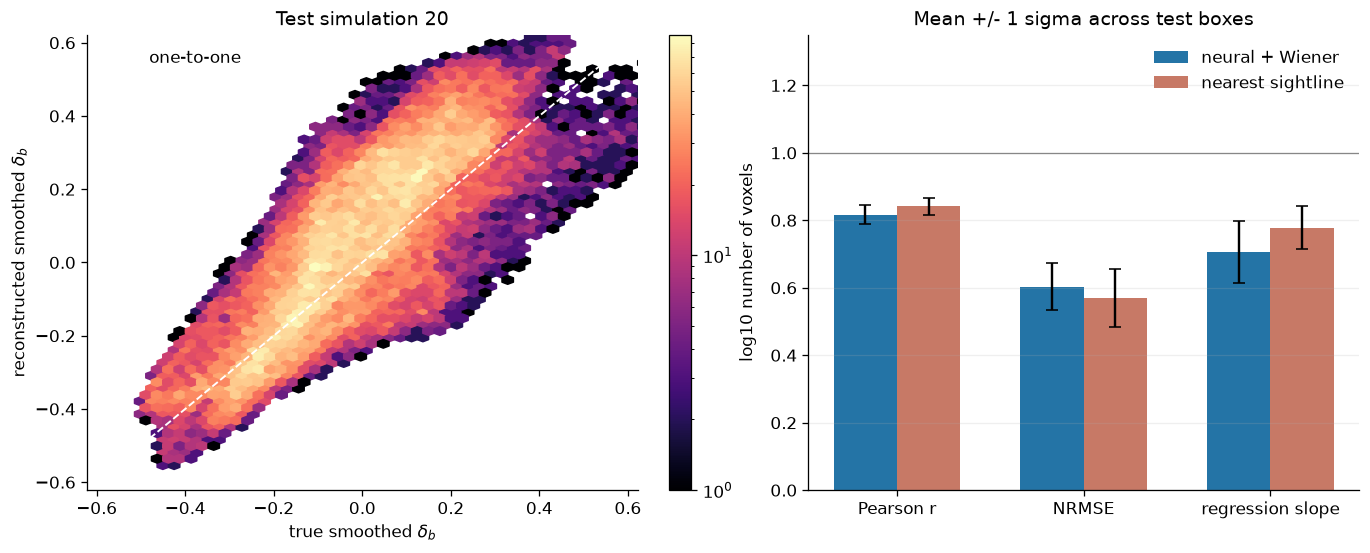

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.7), constrained_layout=True)

plot_limit = np.quantile(np.abs(
    np.concatenate((truth.ravel(), reconstruction.ravel()))
), 0.995)
density_plot = axes[0].hexbin(
    truth.ravel(), reconstruction.ravel(), gridsize=60,
    mincnt=1, bins="log", cmap="magma",
)
axes[0].plot([-plot_limit, plot_limit], [-plot_limit, plot_limit],
             color="white", ls="--", lw=1.2, label="one-to-one")
axes[0].set(xlim=(-plot_limit, plot_limit), ylim=(-plot_limit, plot_limit),
            xlabel=r"true smoothed $\delta_b$",
            ylabel=r"reconstructed smoothed $\delta_b$",
            title=f"Test simulation {test_simulations[representative]}")
axes[0].legend()
fig.colorbar(density_plot, ax=axes[0], label="log10 number of voxels")

x_positions = np.arange(3)
width = 0.34
axes[1].bar(x_positions - width/2, wiener_metrics.mean(axis=0), width,
            yerr=wiener_metrics.std(axis=0, ddof=1), capsize=4,
            label="neural + Wiener", color=BLUE)
axes[1].bar(x_positions + width/2, nearest_metrics.mean(axis=0), width,
            yerr=nearest_metrics.std(axis=0, ddof=1), capsize=4,
            label="nearest sightline", color="#C77966")
axes[1].set_xticks(x_positions, metric_names)
axes[1].set(title="Mean +/- 1 sigma across test boxes", ylim=(0, 1.35))
axes[1].axhline(1.0, color=BLACK, lw=0.8, alpha=0.5)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend()
plt.show()

## 13. Three-dimensional summary statistics

No single statistic is sufficient, so we use four complementary diagnostics.

1. **Density PDF:** the one-point distribution of
   $\log_{10}\Delta_b=\log_{10}(1+\delta_b)$.
2. **3D power spectrum:** scale-dependent variance of the density contrast.
3. **Cross-correlation coefficient:**

   $$
   r(k)=\frac{P_{\rm true,rec}(k)}
   {\sqrt{P_{\rm true}(k)P_{\rm rec}(k)}};
   $$

   this tests Fourier-phase agreement independently of amplitude.
4. **Transfer function:**

   $$
   T(k)=\sqrt{P_{\rm rec}(k)/P_{\rm true}(k)};
   $$

   this exposes Wiener amplitude suppression. We expect $T(k)<1$ on poorly
   constrained small scales.

All curves show the mean and simulation-to-simulation standard deviation across
the seven untouched test boxes.

In [22]:
def isotropic_spectra(truth, reconstruction, edges):
    modes = 2.0 * np.pi * np.fft.fftfreq(N_map, d=dx_map)
    kx, ky, kz = np.meshgrid(modes, modes, modes, indexing="ij")
    k_magnitude = np.sqrt(kx**2 + ky**2 + kz**2)

    truth_fourier = np.fft.fftn(truth - truth.mean())
    reconstruction_fourier = np.fft.fftn(
        reconstruction - reconstruction.mean()
    )
    normalization = dx_map**3 / N_map**3

    power_true_grid = normalization * np.abs(truth_fourier)**2
    power_reconstruction_grid = (
        normalization * np.abs(reconstruction_fourier)**2
    )
    power_cross_grid = normalization * np.real(
        truth_fourier * np.conj(reconstruction_fourier)
    )

    power_true, power_reconstruction, correlation, transfer = [], [], [], []
    for low, high in zip(edges[:-1], edges[1:]):
        selected = (k_magnitude >= low) & (k_magnitude < high)
        if not np.any(selected):
            power_true.append(np.nan)
            power_reconstruction.append(np.nan)
            correlation.append(np.nan)
            transfer.append(np.nan)
            continue

        p_true = power_true_grid[selected].mean()
        p_reconstruction = power_reconstruction_grid[selected].mean()
        p_cross = power_cross_grid[selected].mean()
        power_true.append(p_true)
        power_reconstruction.append(p_reconstruction)
        correlation.append(
            p_cross / np.sqrt(p_true * p_reconstruction)
        )
        transfer.append(np.sqrt(p_reconstruction / p_true))

    return (np.asarray(power_true), np.asarray(power_reconstruction),
            np.asarray(correlation), np.asarray(transfer))


k_minimum = 2.0 * np.pi / box_size
k_maximum = min(2.0, 0.9 * np.pi / dx_map)
k_edges = np.geomspace(k_minimum, k_maximum, 8)
k_centres = np.sqrt(k_edges[:-1] * k_edges[1:])

spectra = np.asarray([
    isotropic_spectra(truth, reconstruction, k_edges)
    for truth, reconstruction in zip(true_smoothed, wiener_smoothed)
])

true_log_density = np.log10(np.clip(1.0 + true_smoothed, 1.0e-4, None))
wiener_log_density = np.log10(np.clip(1.0 + wiener_smoothed, 1.0e-4, None))
pdf_edges = np.linspace(
    np.quantile(true_log_density, 0.002),
    np.quantile(true_log_density, 0.998),
    34,
)
pdf_centres = 0.5 * (pdf_edges[:-1] + pdf_edges[1:])
true_pdfs = np.asarray([
    np.histogram(volume, bins=pdf_edges, density=True)[0]
    for volume in true_log_density
])
wiener_pdfs = np.asarray([
    np.histogram(volume, bins=pdf_edges, density=True)[0]
    for volume in wiener_log_density
])

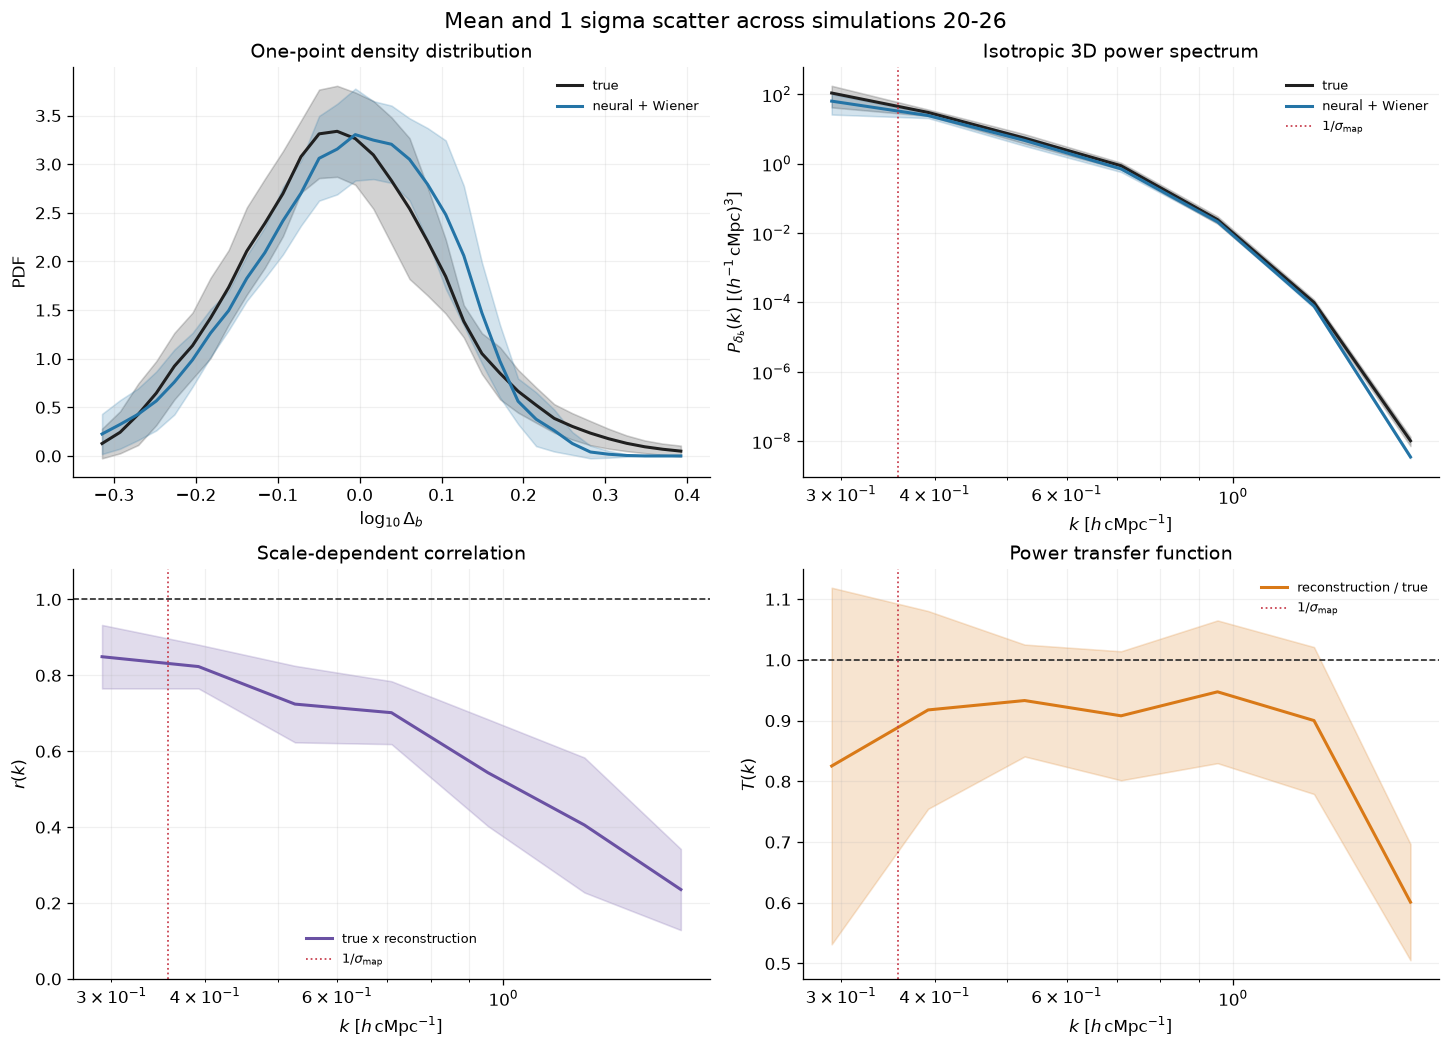

In [23]:
def mean_with_band(axis, x_values, samples, label, colour):
    mean = np.nanmean(samples, axis=0)
    standard_deviation = np.nanstd(samples, axis=0, ddof=1)
    valid = np.isfinite(mean)
    axis.plot(x_values[valid], mean[valid], color=colour,
              lw=1.9, label=label)
    axis.fill_between(
        x_values[valid],
        (mean-standard_deviation)[valid],
        (mean+standard_deviation)[valid],
        color=colour, alpha=0.20,
    )


fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0),
                         constrained_layout=True)

mean_with_band(axes[0, 0], pdf_centres, true_pdfs, "true", BLACK)
mean_with_band(axes[0, 0], pdf_centres, wiener_pdfs,
               "neural + Wiener", BLUE)
axes[0, 0].set(xlabel=r"$\log_{10}\Delta_b$", ylabel="PDF",
               title="One-point density distribution")

mean_with_band(axes[0, 1], k_centres, spectra[:, 0, :], "true", BLACK)
mean_with_band(axes[0, 1], k_centres, spectra[:, 1, :],
               "neural + Wiener", BLUE)
axes[0, 1].set(xlabel=r"$k\ [h\,\mathrm{cMpc}^{-1}]$",
               ylabel=r"$P_{\delta_b}(k)\ [(h^{-1}\,\mathrm{cMpc})^3]$",
               title="Isotropic 3D power spectrum",
               xscale="log", yscale="log")

mean_with_band(axes[1, 0], k_centres, spectra[:, 2, :],
               "true x reconstruction", PURPLE)
axes[1, 0].axhline(1.0, color=BLACK, ls="--", lw=1.0)
axes[1, 0].set(xlabel=r"$k\ [h\,\mathrm{cMpc}^{-1}]$",
               ylabel=r"$r(k)$", title="Scale-dependent correlation",
               xscale="log", ylim=(0.0, 1.08))

mean_with_band(axes[1, 1], k_centres, spectra[:, 3, :],
               "reconstruction / true", ORANGE)
axes[1, 1].axhline(1.0, color=BLACK, ls="--", lw=1.0)
axes[1, 1].set(xlabel=r"$k\ [h\,\mathrm{cMpc}^{-1}]$",
               ylabel=r"$T(k)$", title="Power transfer function",
               xscale="log")

for axis in (axes[0, 1], axes[1, 0], axes[1, 1]):
    axis.axvline(1.0 / map_smoothing_scale, color=RED, ls=":", lw=1.1,
                 label=r"$1/\sigma_{\rm map}$")

for axis in axes.flat:
    axis.grid(alpha=0.18, which="both")
    axis.legend(fontsize=8)

fig.suptitle("Mean and 1 sigma scatter across simulations 20-26", fontsize=14)
plt.show()

## 14. How to interpret the result

A healthy reconstruction should show:

- coherent large-scale overdensities and underdensities at the correct locations;
- a clear improvement over nearest-sightline assignment;
- high $r(k)$ at $k\lesssim1/\sigma_{\rm map}$, followed by a decline toward
  smaller scales;
- a transfer function below unity where the sparse data and Wiener prior suppress
  unconstrained power;
- a narrower reconstructed PDF because rare density peaks are difficult for both
  the neural inverse and the sparse 3D interpolation.

The reconstruction is a **posterior mean under an assumed covariance**, not a new
hydrodynamic realization. It is expected to be smoother than the true field. The
main approximations are the Gaussian covariance, diagonal effective neural-error
term, periodic box, and omission of peculiar velocities.

## References for Wiener Ly$\alpha$ tomography

- Pichon et al. (2001), Bayesian reconstruction of the density field from the
  Ly$\alpha$ forest: [arXiv:astro-ph/0105196](https://arxiv.org/abs/astro-ph/0105196).
- Lee et al. (2014), observational requirements and covariance-scale choices for
  Ly$\alpha$ tomography: [arXiv:1309.1477](https://arxiv.org/abs/1309.1477).
- Stark et al. (2015), Wiener-estimator implementation for Ly$\alpha$ maps:
  [arXiv:1412.1507](https://arxiv.org/abs/1412.1507).
- Özbek et al. (2016), reconstruction tests and correlation lengths of order the
  sightline spacing: [MNRAS 456, 3610](https://academic.oup.com/mnras/article/456/4/3610/1032151).

The standard literature application reconstructs flux contrast. Here the same
linear interpolation machinery is applied **after** the neural network has mapped
each observed spectrum into baryonic density contrast.

## Take-away

The complete reconstruction is

$$
F_{\rm Ly\alpha}^{\rm sparse}
\xrightarrow{\text{1D U-Net}}
\delta_b^{\rm sparse}
\xrightarrow{\text{Wiener filter}}
\widehat{\delta}_b^{\rm 3D}.
$$

The U-Net performs the nonlinear physical inversion along observed sightlines;
the Wiener filter performs transparent covariance-weighted interpolation between
them. Their errors should be diagnosed separately before judging the final 3D map.